# Normalisatie

Normalisatie is een maatregel die wordt gebruikt in machine learning en gegevensverwerking om de schaal van functies of gegevenspunten aan te passen aan een gemeenschappelijk bereik of verdeling. Dit is belangrijk omdat veel machine learning-algoritmen gevoelig zijn voor de schaal van invoerfuncties, en normalisatie helpt ervoor te zorgen dat alle functies gelijk bijdragen aan het leerproces van het model.

We zullen kijken naar twee normalisatietechnieken:
1. **Standard Normal Variate (SNV)**: Een specifieke vorm van normalisatie die vaak wordt gebruikt in spectroscopie. Het houdt in dat de gegevens worden gecentreerd door het gemiddelde af te trekken en te schalen met de standaardafwijking voor elk individueel spectrum. De formule is:
    $\begin{equation}
    X_{snv} = \frac{X - \bar{X}}{s}
    \end{equation}$

    waarbij \(X\) het oorspronkelijke spectrum is, $(\bar{X})$ het gemiddelde van het spectrum is, en \(s\) de standaardafwijking van het spectrum is.

2. **Total Area Normalization (TAN)**: Deze methode schaalt de gegevens zodat de totale oppervlakte onder het spectrum gelijk is aan één. Dit is bijzonder nuttig in de spectroscopie om rekening te houden met variaties in monsterconcentratie of padlengte.
   \begin{equation}
   X_{area} = \frac{X}{\sum{X}}
   \end{equation}

We zullen het effect van deze normalisatietechnieken op onze dataset onderzoeken en hun impact op de prestaties van onze machine learning-modellen. SNV en TAN zullen we het handmatig moeten implementeren.

We zullen de prestaties van onze modellen vergelijken met behulp van de cross-validatie-accuratesse en validatie-accuratesse van een random forest en een logistische regressie-classificator.

![Voorbeeld verschillen normalisatie methoden](../assets/images/voorbeeld%20normalisatie.png)

Voorbeeld van verschillen in normalisatie methoden toegepast op een LIBS spectrum.

In [1]:
import numpy as np
import pandas as pd
import os
import sys
project_root = os.path.abspath('..')  # Go up one level from current notebook
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from utils.libs_generic_functions import LibsDataLoader

data_directory = '../data'
data_loader = LibsDataLoader(data_directory)

df = data_loader.load_all_measurements()

MEMORY-EFFICIENT LOADING OF ALL INDIVIDUAL MEASUREMENTS
First pass: Counting measurements...
Processing file 1/316: 2024-11-05T11-26-41_nr-001_B1_tread_aided_10Hz_280A.h5
Processing file 11/316: 2024-11-05T11-51-23_nr-011_B4_innerliner_aided_10Hz_280A.h5
Processing file 21/316: 2024-11-05T12-02-34_nr-021_B7_sidewall_aided_10Hz_280A.h5
Processing file 31/316: 2024-11-05T12-13-30_nr-031_B22_tread_aided_10Hz_280A.h5
Processing file 41/316: 2024-11-05T12-25-42_nr-041_B33_innerliner_aided_10Hz_280A.h5
Processing file 51/316: 2024-11-05T12-36-31_nr-051_B28_sidewall_aided_10Hz_280A.h5
Processing file 61/316: 2024-11-05T12-47-29_nr-061_B15_tread_aided_10Hz_280A.h5
  Counted 10,000 measurements...
Processing file 71/316: 2024-11-05T12-58-45_nr-071_B30_innerliner_aided_10Hz_280A.h5
Processing file 81/316: 2024-11-05T13-17-11_nr-081_B35_innerliner_aided_10Hz_280A.h5
Processing file 91/316: 2024-11-05T14-05-16_nr-091_B26_sidewall_aided_10Hz_280A.h5
Processing file 101/316: 2024-11-05T14-16-52_nr-1

In [2]:
X_data = df.drop(columns=['origin', 'tire_number', 'measurement_id']).values.astype(np.float32)
y_data = df['origin'].values

In [5]:
# === NORMALIZATION METHODS COMPARISON ===
import time
import numpy as np
print("="*80)
print("COMPARING STANDARD NORMAL VARIATE (SNV) vs TOTAL AREA NORMALIZATION")
print("="*80)

def standard_normal_variate(spectra_matrix):
    """
    Apply Standard Normal Variate (SNV) normalization to spectra
    
    SNV removes multiplicative scatter effects by centering and scaling each spectrum 
    individually to unit variance.
    
    Formula: SNV(x) = (x - mean(x)) / std(x)
    
    Parameters:
    spectra_matrix: 2D array where each row is a spectrum
    
    Returns:
    normalized_spectra: SNV-normalized spectra
    """
    print(f"Applying SNV normalization to {len(spectra_matrix)} spectra...")
    
    # Calculate mean and std for each spectrum (row-wise)
    means = np.mean(spectra_matrix, axis=1, keepdims=True)
    stds = np.std(spectra_matrix, axis=1, keepdims=True, ddof=0)
    
    # Avoid division by zero
    stds = np.where(stds == 0, 1, stds)
    
    # Apply SNV normalization
    normalized_spectra = (spectra_matrix - means) / stds
    
    return normalized_spectra.astype(np.float32)


def apply_total_area_normalization(X_train, X_test):
    """
    Apply Total Area Normalization to spectra
    
    Total Area Normalization scales each spectrum so that the area under the curve (sum of intensities)
    is equal to 1. This removes differences in overall intensity due to varying sample amounts.
    
    Formula: TAN(x) = x / sum(x)
    """
    print("Applying Total Area Normalization...")
    
    def normalize_spectrum(spectrum):
        total_area = np.sum(spectrum)
        if total_area == 0:
            return spectrum  # Avoid division by zero
        return spectrum / total_area
    
    X_train_normalized = np.array([normalize_spectrum(spectrum) for spectrum in X_train])
    X_test_normalized = np.array([normalize_spectrum(spectrum) for spectrum in X_test])
    
    return X_train_normalized.astype(np.float32), X_test_normalized.astype(np.float32)

def compare_normalization_methods(X_data, y_data, test_size=0.3, random_state=42):
    """
    Comprehensive comparison of normalization methods
    """
    from sklearn.model_selection import train_test_split
    
    # Split data once for fair comparison
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=test_size, random_state=random_state, stratify=y_data
    )
    
    print(f"Dataset split: Train={X_train.shape}, Test={X_test.shape}")
    
    # Define normalization methods
    normalization_results = {}
    
    # 1. No normalization (baseline)
    print("\n--- No Normalization ---")
    normalization_results['No Normalization'] = {
        'X_train': X_train.copy(),
        'X_test': X_test.copy(),
        'description': 'Raw data without any normalization'
    }
    
    # 2. Standard Normal Variate (SNV)
    print("\n--- Standard Normal Variate (SNV) ---")
    start_time = time.time()
    X_train_snv = standard_normal_variate(X_train)
    X_test_snv = standard_normal_variate(X_test)
    snv_time = time.time() - start_time
    
    normalization_results['SNV'] = {
        'X_train': X_train_snv,
        'X_test': X_test_snv,
        'description': 'Row-wise normalization of each spectrum individually',
        'processing_time': snv_time
    }
    print(snv_time)
    # 3. Total Area Normalization (TAN)
    print("\n--- Total Area Normalization (TAN) ---")
    start_time = time.time()
    X_train_tan, X_test_tan = apply_total_area_normalization(X_train, X_test)
    tan_time = time.time() - start_time

    normalization_results['Total Area Normalization'] = {
        'X_train': X_train_tan,
        'X_test': X_test_tan,
        'description': 'Normalization to unit area under each spectrum',
        'processing_time': tan_time
    }

    return normalization_results, y_train, y_test


X_data = df.drop(columns=['origin', 'tire_number', 'measurement_id']).values.astype(np.float32)
y_data = df['origin'].values

# X_test_data = X_test.drop(columns=['origin', 'tire_number', 'measurement_id']).values.astype(np.float32)
# y_test_data = y_test_encoded.values


# Apply normalization comparison
norm_results, y_train_norm, y_test_norm = compare_normalization_methods(
    X_data, y_data, test_size=0.3, random_state=42
)

print(f"\nNormalization methods applied successfully!")

COMPARING STANDARD NORMAL VARIATE (SNV) vs TOTAL AREA NORMALIZATION
Dataset split: Train=(36017, 6699), Test=(15436, 6699)

--- No Normalization ---

--- Standard Normal Variate (SNV) ---
Applying SNV normalization to 36017 spectra...
Applying SNV normalization to 15436 spectra...
11.816776514053345

--- Total Area Normalization (TAN) ---
Applying Total Area Normalization...

Normalization methods applied successfully!


In [ ]:
# === MACHINE LEARNING COMPARISON WITH DIFFERENT NORMALIZATIONS ===
print("\n" + "="*80)
print("ML PERFORMANCE COMPARISON: NORMALIZATION METHODS")
print("="*80)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score


# Define models for testing
models_norm = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=500, solver='liblinear'),
    'SVM': None  # We'll skip SVM for now to keep it manageable
}

# Remove SVM for this comparison to focus on the main models
models_norm = {k: v for k, v in models_norm.items() if k != 'SVM'}

# Store comprehensive results
normalization_ml_results = {}

# Test each normalization method
for norm_name, norm_data in norm_results.items():
    print(f"\n--- Testing {norm_name} ---")
    print(f"Description: {norm_data['description']}")
    
    X_train_norm = norm_data['X_train']
    X_test_norm = norm_data['X_test']
    
    # Check for any issues with normalized data
    print(f"Data quality check:")
    print(f"  Train: NaN={np.isnan(X_train_norm).sum()}, Inf={np.isinf(X_train_norm).sum()}")
    print(f"  Test:  NaN={np.isnan(X_test_norm).sum()}, Inf={np.isinf(X_test_norm).sum()}")
    
    # Handle any data quality issues
    if np.isnan(X_train_norm).sum() > 0 or np.isinf(X_train_norm).sum() > 0:
        print("  Fixing data quality issues...")
        X_train_norm = np.nan_to_num(X_train_norm, nan=0.0, posinf=1.0, neginf=-1.0)
        X_test_norm = np.nan_to_num(X_test_norm, nan=0.0, posinf=1.0, neginf=-1.0)
    
    normalization_ml_results[norm_name] = {}
    
    # Test each model
    for model_name, model in models_norm.items():
        print(f"  {model_name}:")
        
        start_time = time.time()
        
        # Cross-validation
        cv_scores = cross_val_score(
            model, X_train_norm, y_train_norm,
            cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=42),
            scoring='accuracy'
        )
        
        # Validation accuracy
        model.fit(X_train_norm, y_train_norm)
        y_pred = model.predict(X_test_norm)
        val_accuracy = accuracy_score(y_test_norm, y_pred)
        
        training_time = time.time() - start_time
        
        # Store results
        normalization_ml_results[norm_name][model_name] = {
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'val_accuracy': val_accuracy,
            'training_time': training_time,
            'processing_time': norm_data.get('processing_time', 0)
        }
        
        print(f"    CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
        print(f"    Val Accuracy: {val_accuracy:.4f}")
        print(f"    Training Time: {training_time:.2f}s")

print(f"\nNormalization comparison completed!")


## Machine learning prestaties vergelijking: Normalisatie methoden


--- Testing No Normalization ---
Description: Raw data without any normalization
Data quality check:

  Train: NaN=0, Inf=0

  Test:  NaN=0, Inf=0

  Random Forest:

    CV Accuracy: 0.8957 ± 0.0006
    Val Accuracy: 0.9184
    Training Time: 110.43s

  Logistic Regression:

    CV Accuracy: 0.9600 ± 0.0005
    Val Accuracy: 0.9661
    Training Time: 9283.49s


--- Testing SNV ---

Description: Row-wise normalization of each spectrum individually

Data quality check:

  Train: NaN=0, Inf=0

  Test:  NaN=0, Inf=0

  Random Forest:

    CV Accuracy: 0.9375 ± 0.0021
    Val Accuracy: 0.9531
    Training Time: 136.81s

  Logistic Regression:
  
    CV Accuracy: 0.9571 ± 0.0006
    Val Accuracy: 0.9665
    Training Time: 2952.88s

--- Testing Total Area Normalization ---

Description: Normalization to unit area under each spectrum

Data quality check:

  Train: NaN=0, Inf=0

  Test:  NaN=0, Inf=0

  Random Forest:

    CV Accuracy: 0.9379 ± 0.0024
    Val Accuracy: 0.9548
    Training Time: 86.94s

  Logistic Regression:

    CV Accuracy: 0.3487 ± 0.0001
    Val Accuracy: 0.3616
    Training Time: 89.70s

Normalization comparison completed!

In [ ]:
# === DETAILED STATISTICAL ANALYSIS ===
print("\n" + "="*80)
print("DETAILED STATISTICAL ANALYSIS OF NORMALIZATION METHODS")
print("="*80)

# Create norm_df from normalization_ml_results
norm_data_list = []
for norm_method, models_results in normalization_ml_results.items():
    for model_name, results in models_results.items():
        norm_data_list.append({
            'Normalization': norm_method,
            'Model': model_name,
            'Val_Accuracy': results['val_accuracy']
        })

import pandas as pd
norm_df = pd.DataFrame(norm_data_list)

# Statistical significance testing
from scipy import stats

print("=== STATISTICAL SIGNIFICANCE TESTING ===")

# Get results for all normalization methods
snv_results = norm_df[norm_df['Normalization'] == 'SNV']['Val_Accuracy'].values
tan_results = norm_df[norm_df['Normalization'] == 'Total Area Normalization']['Val_Accuracy'].values
none_results = norm_df[norm_df['Normalization'] == 'No Normalization']['Val_Accuracy'].values

# Effect size (Cohen's d) function
def cohens_d(x, y):
    if len(x) <= 1 or len(y) <= 1:
        return 0  # Cannot calculate effect size with insufficient data
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / dof)
    if pooled_std == 0:
        return 0  # No variance, no effect
    return (np.mean(x) - np.mean(y)) / pooled_std

def get_effect_description(effect_size):
    if abs(effect_size) < 0.2:
        return "negligible"
    elif abs(effect_size) < 0.5:
        return "small"
    elif abs(effect_size) < 0.8:
        return "medium"
    else:
        return "large"

# Perform pairwise comparisons
comparisons = [
    ('SNV', 'StandardScaler', snv_results, std_results),
    ('SNV', 'Total Area Normalization', snv_results, tan_results),
    ('SNV', 'No Normalization', snv_results, none_results),
    ('StandardScaler', 'Total Area Normalization', std_results, tan_results),
    ('StandardScaler', 'No Normalization', std_results, none_results),
    ('Total Area Normalization', 'No Normalization', tan_results, none_results)
]

print(f"{'Comparison':<35} {'T-stat':<8} {'P-value':<8} {'Significant':<12} {'Effect Size':<12} {'Effect':<12}")
print("-" * 95)

for method1, method2, results1, results2 in comparisons:
    if len(results1) > 1 and len(results2) > 1:
        t_stat, p_value = stats.ttest_rel(results1, results2)
        effect_size = cohens_d(results1, results2)
        significant = 'Yes' if p_value < 0.05 else 'No'
        effect_desc = get_effect_description(effect_size)
        
        comparison_name = f"{method1[:8]} vs {method2[:8]}"
        print(f"{comparison_name:<35} {t_stat:<8.3f} {p_value:<8.3f} {significant:<12} {effect_size:<12.3f} {effect_desc:<12}")
    else:
        comparison_name = f"{method1[:8]} vs {method2[:8]}"
        print(f"{comparison_name:<35} {'N/A':<8} {'N/A':<8} {'N/A':<12} {'N/A':<12} {'N/A':<12}")

# === COMPREHENSIVE PERFORMANCE ANALYSIS ===
print(f"\n=== COMPREHENSIVE PERFORMANCE ANALYSIS ===")

# Calculate summary statistics for each normalization method
method_stats = []
for method in norm_df['Normalization'].unique():
    method_data = norm_df[norm_df['Normalization'] == method]['Val_Accuracy']
    method_stats.append({
        'Method': method,
        'Mean_Accuracy': method_data.mean(),
        'Std_Accuracy': method_data.std(),
        'Max_Accuracy': method_data.max(),
        'Min_Accuracy': method_data.min(),
        'Count': len(method_data)
    })

stats_df = pd.DataFrame(method_stats)
stats_df = stats_df.sort_values('Mean_Accuracy', ascending=False)

print(f"{'Method':<25} {'Mean Acc':<10} {'Std':<8} {'Max Acc':<10} {'Min Acc':<10} {'Count':<8}")
print("-" * 75)

for _, row in stats_df.iterrows():
    print(f"{row['Method']:<25} {row['Mean_Accuracy']:<10.4f} {row['Std_Accuracy']:<8.4f} "
          f"{row['Max_Accuracy']:<10.4f} {row['Min_Accuracy']:<10.4f} {row['Count']:<8}")

print(f"\n📊 PERFORMANCE SUMMARY:")
best_results = {}
for method in norm_df['Normalization'].unique():
    best_acc = norm_df[norm_df['Normalization'] == method]['Val_Accuracy'].max()
    mean_acc = norm_df[norm_df['Normalization'] == method]['Val_Accuracy'].mean()
    best_results[method] = {'best': best_acc, 'mean': mean_acc}

# Sort by mean accuracy
sorted_methods = sorted(best_results.items(), key=lambda x: x[1]['mean'], reverse=True)

for i, (method, results) in enumerate(sorted_methods, 1):
    print(f"   {i}. {method:<25}: Best={results['best']:.4f}, Mean={results['mean']:.4f}")

winner = sorted_methods[0]
print(f"\n🏆 OVERALL WINNER: {winner[0]}")
print(f"   Mean Accuracy: {winner[1]['mean']:.4f}")
print(f"   Best Accuracy: {winner[1]['best']:.4f}")

# Calculate improvements over no normalization
if 'No Normalization' in best_results:
    baseline_mean = best_results['No Normalization']['mean']
    print(f"\n📈 IMPROVEMENTS OVER NO NORMALIZATION:")
    
    for method, results in sorted_methods:
        if method != 'No Normalization':
            improvement = results['mean'] - baseline_mean
            improvement_pct = (improvement / baseline_mean) * 100
            print(f"   {method:<25}: {improvement:+.4f} ({improvement_pct:+.1f}%)")


VISUALIZING NORMALIZATION EFFECTS ON A SINGLE SPECTRUM
Applying SNV normalization to 1 spectra...


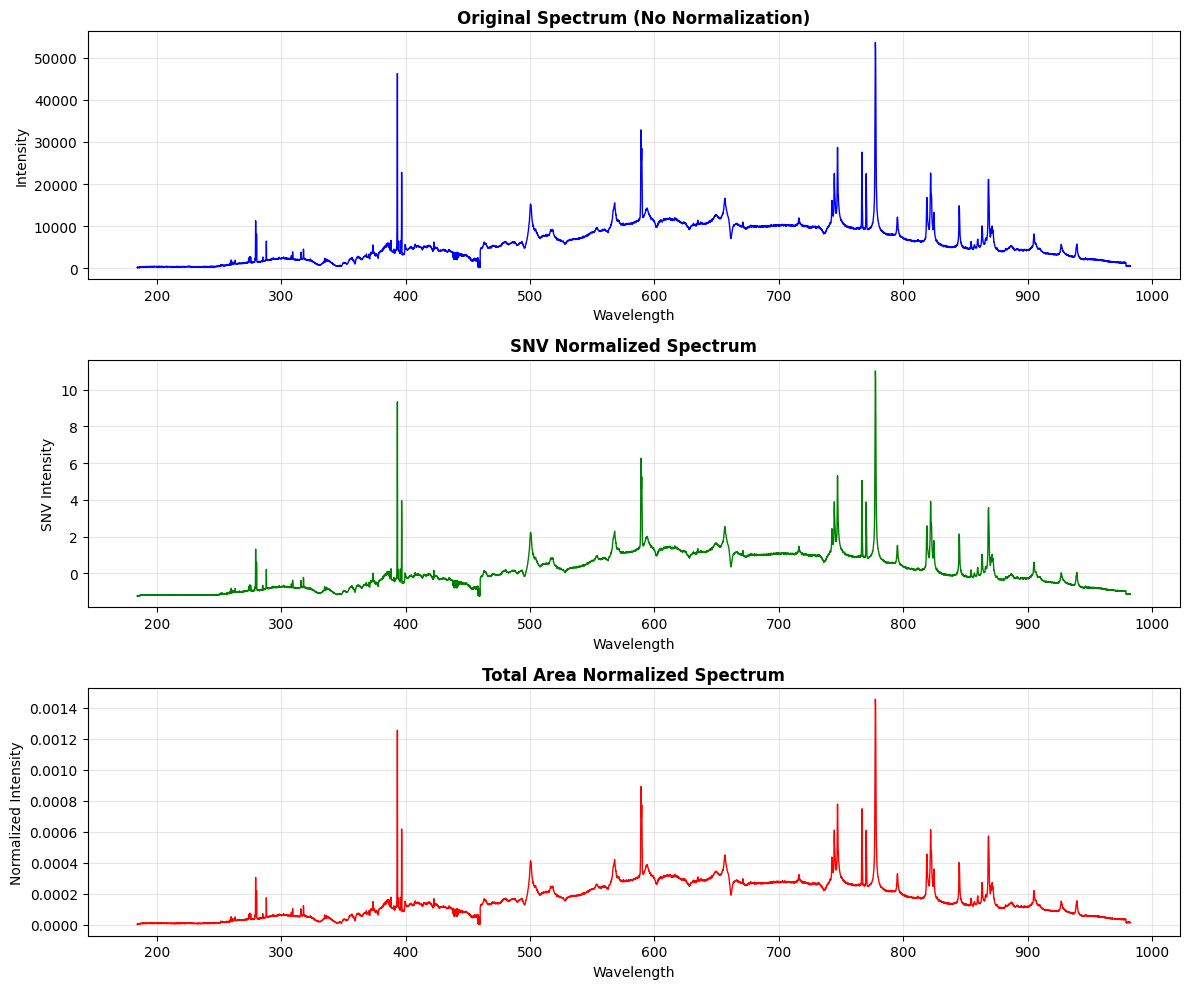


Spectrum Statistics:
Method                    Mean         Std          Min          Max          Sum         
-------------------------------------------------------------------------------------
Original                  5508.5537    4369.4360    77.0000      53629.0000   36901800.0000
SNV                       0.0000       1.0000       -1.2431      11.0130      0.0002      
TAN                       0.0001       0.0001       0.0000       0.0015       1.0000      


In [26]:
# === VISUALIZE NORMALIZATION EFFECTS ON A SINGLE SPECTRUM ===
import matplotlib.pyplot as plt

print("="*80)
print("VISUALIZING NORMALIZATION EFFECTS ON A SINGLE SPECTRUM")
print("="*80)

df_visualization = df.drop(columns=['origin', 'tire_number', 'measurement_id'])
sample = df_visualization.iloc[1]
original_spectrum = sample.values.astype(np.float32)

# Apply SNV to the spectrum
snv_spectrum = standard_normal_variate(original_spectrum.reshape(1, -1)).flatten()

# Apply TAN to the spectrum
tan_spectrum = original_spectrum / np.sum(original_spectrum)

# Create wavelength axis (assuming sequential wavelength indices)
sample = sample.to_numpy()
wavelengths = df_visualization.columns.astype(float)

# Create figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot original spectrum
axes[0].plot(wavelengths, original_spectrum, color='blue', linewidth=1)
axes[0].set_title('Original Spectrum (No Normalization)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Wavelength')
axes[0].set_ylabel('Intensity')
axes[0].grid(True, alpha=0.3)

# Plot SNV normalized spectrum
axes[1].plot(wavelengths, snv_spectrum, color='green', linewidth=1)
axes[1].set_title('SNV Normalized Spectrum', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Wavelength')
axes[1].set_ylabel('SNV Intensity')
axes[1].grid(True, alpha=0.3)

# Plot TAN normalized spectrum
axes[2].plot(wavelengths, tan_spectrum, color='red', linewidth=1)
axes[2].set_title('Total Area Normalized Spectrum', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Wavelength')
axes[2].set_ylabel('Normalized Intensity')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics for comparison
print(f"\nSpectrum Statistics:")
print(f"{'Method':<25} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12} {'Sum':<12}")
print("-" * 85)
print(f"{'Original':<25} {np.mean(original_spectrum):<12.4f} {np.std(original_spectrum):<12.4f} "
    f"{np.min(original_spectrum):<12.4f} {np.max(original_spectrum):<12.4f} {np.sum(original_spectrum):<12.4f}")
print(f"{'SNV':<25} {np.mean(snv_spectrum):<12.4f} {np.std(snv_spectrum):<12.4f} "
    f"{np.min(snv_spectrum):<12.4f} {np.max(snv_spectrum):<12.4f} {np.sum(snv_spectrum):<12.4f}")
print(f"{'TAN':<25} {np.mean(tan_spectrum):<12.4f} {np.std(tan_spectrum):<12.4f} "
    f"{np.min(tan_spectrum):<12.4f} {np.max(tan_spectrum):<12.4f} {np.sum(tan_spectrum):<12.4f}")

In [22]:
wavelengths.tolist()
wavelengths = pd.Index(df_visualization.columns)
print(wavelengths)

Index(['184.3', '184.4', '184.5', '184.6', '184.7', '184.8', '184.9', '185.0',
       '185.1', '185.2',
       ...
       '981.3', '981.4', '981.5', '981.7', '981.8', '981.9', '982.0', '982.1',
       '982.2', '982.4'],
      dtype='object', length=6699)


In [24]:
df_visualization.columns.astype(float)

Index([184.3, 184.4, 184.5, 184.6, 184.7, 184.8, 184.9, 185.0, 185.1, 185.2,
       ...
       981.3, 981.4, 981.5, 981.7, 981.8, 981.9, 982.0, 982.1, 982.2, 982.4],
      dtype='float64', length=6699)